Equipe:

Matheus Nunes

Lucas Ribeiro

Ana Clara Didier

#Dependencias

In [ ]:
from sklearn.neural_network import MLPClassifier # Verificar API para mais parâmetros

In [ ]:
from scipy.stats import mode
import numpy as np
import pandas as pd
import matplotlib.pyplot as matplot
import matplotlib
%matplotlib inline

import random
matplot.rcdefaults()
from itertools import chain
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import plotly.express as px

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from keras.datasets import mnist

#Dados

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
nsamples, nx, ny = X_train.shape
d2_train_dataset = X_train.reshape((nsamples,nx*ny))

In [ ]:
nsamples, nx, ny = X_test.shape
d2_test_dataset = X_test.reshape((nsamples,nx*ny))

#Modelo inicial

In [ ]:
model = MLPClassifier(hidden_layer_sizes=(100, 75, 50), max_iter=300,)
model.fit(d2_train_dataset, y_train)

ValueError: ignored

In [ ]:
model.predict(d2_train_dataset)

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
accuracy_score(y_test, model.predict(d2_test_dataset))

0.9716

In [ ]:
model.best_loss_


0.00805011276319865

#Modelo Robusto - Grid Search

In [ ]:
i = 0
df = pd.DataFrame(columns = ['alpha','max_iter','train_acc','test_acc'])
for a in [0.00001,0.0001,0.001,0.01, 0.1, 1]:
    for mi in [10,100,200,500,]:
        model = MLPClassifier(alpha=a, max_iter=mi)
        model.fit(d2_train_dataset, y_train)

        acc_tr = accuracy_score(y_train, model.predict(d2_train_dataset)) # Train Accuracy
        acc = accuracy_score(y_test, model.predict(d2_test_dataset)) # Test Accuracy
        df.loc[i] = [a,mi,acc_tr,acc]
        i=i+1

In [ ]:
df

,alpha,max_iter,train_acc,test_acc
0,0.00001,10.0,0.966100,0.9431
1,0.00001,100.0,0.992350,0.9622
2,0.00001,200.0,0.991817,0.9622
3,0.00001,500.0,0.989933,0.9633
4,0.00010,10.0,0.964883,0.9422
5,0.00010,100.0,0.994233,0.9661
6,0.00010,200.0,0.994983,0.9651
7,0.00010,500.0,0.996033,0.9726
8,0.00100,10.0,0.960633,0.9415
9,0.00100,100.0,0.991117,0.9651


	0.00010	500.0	    0.996033	 0.9726
  alpha	 | max_iter |	train_acc |	test_acc

In [ ]:
acc_list = []
acc_tr_list = []
timelog = []
for l in [10,20,50,100,200,500,1000]:
    mlp = MLPClassifier(alpha=0.00010, max_iter=500, hidden_layer_sizes=(l,))
    model.fit(d2_train_dataset, y_train)

    acc_tr = accuracy_score(y_train, model.predict(d2_train_dataset)) # Train Accuracy
    acc = accuracy_score(y_test, model.predict(d2_test_dataset))

    acc_tr_list.append(acc_tr)
    acc_list.append(acc)

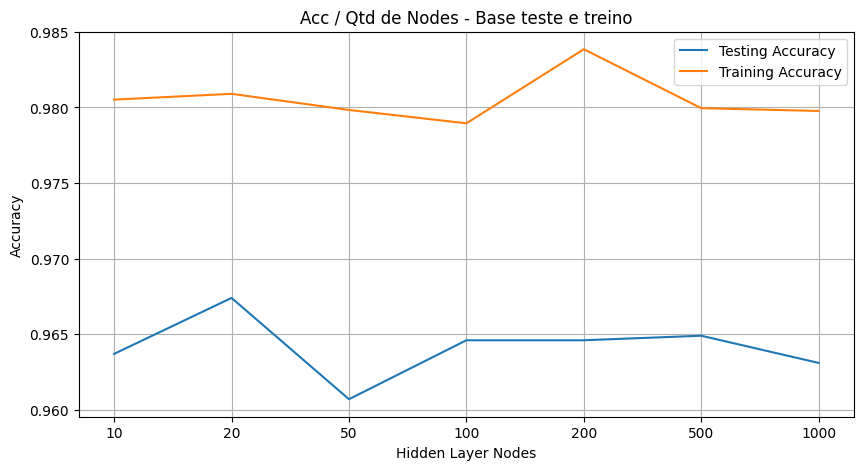

In [ ]:
l = [10,20,50,100,200,500,1000]
N = len(l)
l2 = np.arange(N)
matplot.subplots(figsize=(10, 5))
matplot.plot(l2, acc_list, label="Testing Accuracy")
matplot.plot(l2, acc_tr_list, label="Training Accuracy")
matplot.xticks(l2,l)
matplot.grid(True)
matplot.xlabel("Hidden Layer Nodes")
matplot.ylabel("Accuracy")
matplot.legend()
matplot.title('Acc / Qtd de Nodes - Base teste e treino', fontsize=12)
matplot.show()

Melhor quantidade de Nodes é 20



#Modelo com melhores hiperparametros

In [ ]:
mlp = MLPClassifier(alpha=0.00010, max_iter=500, hidden_layer_sizes=(20,))
model.fit(d2_train_dataset, y_train)

acc_tr = accuracy_score(y_train, model.predict(d2_train_dataset))
acc = accuracy_score(y_test, model.predict(d2_test_dataset))

0.9691

##Métricas de perfomance

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
acc_tr

0.9835

In [ ]:
acc

0.9691

In [ ]:
precision_score(y_test, model.predict(d2_test_dataset),average='weighted', zero_division=1)

0.9692624229700488

##Loss Curve

In [ ]:
px.line(list(model.loss_curve_))

In [ ]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, model.predict(d2_test_dataset))

##Matriz de Confusão

In [ ]:
px.imshow(cm,text_auto=True,aspect='auto')